# plot_results.ipynb

plot results from betacomp.ipynb

Set directories and parameters

In [2]:
### PATHS AND DIRECTORIES ###
# Location of .spec files
# p_spec_dir = "/Users/ivandevert/projects/ridgecrest2019_prev/proc/spectral/01_compspec/SPECOUT/"
p_results_path = "/Users/ivandevert/projects/spectral_falloff_ratio/data/beta/betaout_p.txt"
s_results_path = "/Users/ivandevert/projects/spectral_falloff_ratio/data/beta/betaout_s.txt"


# p_results_path = "/Users/ivandevert/projects/spectral_falloff_ratio/data/beta/syn_betaout_p.txt"


# Location of earthquake catalog containing stress drop estimates
delsig_p_catalog_path = "/Users/ivandevert/projects/ridgecrest2019_prev/comparisons/p_s_comparison/final/ridgecrest_stressdrop_p.txt"
delsig_s_catalog_path = "/Users/ivandevert/projects/ridgecrest2019_prev/comparisons/p_s_comparison/final/ridgecrest_stressdrop_s.txt"

# Location of spectra.pkl file/where to save it
paper_figure_dir = "/Users/ivandevert/Documents/papers/high_freq_ratio/paper_name_pre_submission/figs/"


### INPUT DATA PARAMETERS ###
# phase = 'p' 
# phase = 's' 
units = ['h', 'n']

# Beta computation params
stn_f_range = [2.5, 6.0]
dist_min = 0
dist_max = 100

### P-WAVE PARAMETERS ###
low_beta_window_p = [1, 5]
high_beta_window_p = [15, 22]
calib_mag_range_p = [1.4, 1.6]

### S-WAVE PARAMETERS ###
low_beta_window_s = [1, 5]
high_beta_window_s = [15, 22]
calib_mag_range_s = [1.9, 2.1]

# calibration event parameters
calib_rmax = 5.0
calib_zmax = 1.0
calib_stn_req = 3.0
ncalib_min = 10

# miscellaneous parameters
xsec_dmax = 1500
f_nyquist = 50.0
nf = 65

low_beta_window = [1, 5]
high_beta_window = [15, 22]


# process some of the parameters
units = [el.upper() for el in units]

# if phase == 'p':
#     components = ['Z']
#     calib_mag_range = calib_mag_range_p
#     low_beta_window = low_beta_window_p
#     high_beta_window = high_beta_window_p
#     spec_dir = p_spec_dir
# elif phase == 's':
#     components = ['N', 'E', '1', '2']

#     calib_mag_range = calib_mag_range_s
#     low_beta_window = low_beta_window_s
#     high_beta_window = high_beta_window_s
#     spec_dir = s_spec_dir


In [3]:
# %matplotlib ipympl


import numpy as np
import scipy
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
import struct
import math
import time
import sys
import string

sys.path.append('..')

import stressdrop_file_IO as sdio
import seismo_functions as sf
import mapping_tools as mt
import importlib
importlib.reload(sdio)
import obspy

from scipy import sparse
import utm
import copy 

import ipywidgets as widgets
from ipywidgets import interactive

from shapely.geometry import Point, MultiPoint
from shapely.geometry.polygon import Polygon

from lib.beta_functions import read_beta_files, read_betatxt_files, read_spec_df

from tqdm import trange
from mpl_toolkits.axes_grid1 import make_axes_locatable


In [4]:

A =     np.array([4.33E5, 3.974E6])
Ap =    np.array([4.665E5, 3.938E6])

B =     np.array([4.40E5, 3.9343E6])
Bp =    np.array([4.60E5, 3.9543E6])

Define some functions

In [5]:

def get_colormap(d, cmap='coolwarm_r', method='percentile', **kwargs):

    d = d.astype(float)
    n = len(d)
    
    if method=='percentile':
        assert 'percentiles' in kwargs.keys(), "percentiles must be in kwargs"

        pct = kwargs['percentiles']

        d_sort = np.sort(d)

        cmap = plt.get_cmap(cmap)
        bounds = np.linspace(d_sort[int(pct[0]*n)], d_sort[int(pct[1]*n)], 7)
        norm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='both')

        smap = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    if method=='mediancenter':

        center = np.median(d)
        if 'percentiles' in kwargs.keys():
            pct = kwargs['percentiles']
        else:
            pct = [0.05, 0.95]
        
        d_sort = np.sort(d)

        center_dists = np.array(center - d_sort[int(pct[0]*n)], 
                                d_sort[int(pct[1]*n)] - center)
        dist = np.mean(center_dists)

        cmap = plt.get_cmap(cmap)
        bounds = np.linspace(center-dist, center+dist, 7)
        norm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='both')

        smap = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

    if method=='logmediancenter':
        logd = np.log10(d)
        logcenter = np.median(logd)
        if 'percentiles' in kwargs.keys():
            pct = kwargs['percentiles']
        else:
            pct = [0.05, 0.95]
        
        logd_sort = np.sort(logd)

        center_dists = np.array(logcenter - logd_sort[int(pct[0]*n)], 
                                logd_sort[int(pct[1]*n)] - logcenter)
        dist = np.mean(center_dists)

        cmap = plt.get_cmap(cmap)
        bounds = np.logspace(logcenter-dist, logcenter+dist, 7)
        norm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='both')

        smap = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

    return cmap, smap, norm



def p_norm(v, p):
    """Return the p-norm of a vector v (see ref. [2])

    Args:
        v (np.ndarray): array to calculate p-norm of
        p (int): p for p-norm

    Returns:
        float: p-norm of v
    """
    return np.power(np.sum(np.power(np.abs(v), p)), 1/p)

def model_p_norm(m, model_function, t, d, p):
    """Intermediate function for calculating the p-norm.

    Args:
        m (array-like): array of model parameters
        model_function (function): callable function
        t (np.ndarray): independent variable
        d (np.ndarray): data array
        p (int): p for p-norm

    Returns:
        float: p-norm of the residual (expected - observed) array
    """
    y = model_function(m, t)
    return p_norm(y - d, p)

def fit_p_norm(x, d, model, m0, p):
    """Find a fit to a model using scipy.optimize.minimize()

    Args:
        x (np.ndarray): independent variable
        d (np.ndarray): observations
        model (function): callable function, with inputs m (model 
            params) and x
        m0 (array-like): starting values for model parameters
        p (int): integer for choosing p-norm (1: L1-norm, 2: L2-norm, 
            etc.)

    Returns:
        np.ndarray: Best-fit model parameters
    """
    from scipy.optimize import minimize
    res = minimize(model_p_norm, m0, args=(model, x, d, p))
    return res.x

def line_model(m, x):
    """Slope-intercept form of a line.

    Args:
        m (array-like): (slope, intercept)
        x (np.ndarray): independent variable

    Returns:
        np.ndarray: y values on line
    """
    return m[0] * x + m[1]

def fit_line_p_norm(x, y, p):
    """Fit a simple line to x, y data using the p-norm.

    Args:
        x (np.ndarray): x values of data
        y (np.ndarray): y values of data
        p (np.ndarray): which norm to use to calculate the line 
            parameters. Least-squares when p==2.

    Returns:
        np.ndarray: (slope, intercept) of best-fit line.
    """
    m0 = np.polyfit(x, y, 1)
    return fit_p_norm(x, y, line_model, m0, p)

def compute_logbeta(spectra, low_f_ind, high_f_ind):
    # spectra is an (N x nf) array
    low_band = np.median(np.log10(spectra[:, low_f_ind[0]:low_f_ind[1]+1]), axis=1)
    high_band = np.median(np.log10(spectra[:, high_f_ind[0]:high_f_ind[1]+1]), axis=1)
    logbeta = high_band - low_band
    return logbeta

def boxplot(x, y, xbins, ax=None, color='r', **kwargs):

    if ax is None: ax = plt.gca()
    boxprops = dict(color=color)
    medianprops = dict(color=color, linewidth=2)
    whiskerprops = dict(color=color)
    capprops = dict(color=color)

    # toss out values of x, y where x is outside xbins bounds?
    
    inds = np.digitize(x, bins=xbins) - 1

    xmids = (xbins[1:] + xbins[:-1]) / 2

    xmids = xmids[np.unique(inds)]

    xwidth = xbins[1]-xbins[0]
    
    # get data in proper format for boxplot. This forms a sequence of 1D
    # arrays
    X = [y[inds==i] for i in np.unique(inds)]

    keys = kwargs.keys()
    if 'positions' not in keys: kwargs = {**kwargs, 'positions': xmids}
    if 'manage_ticks' not in keys: kwargs = {**kwargs, 'manage_ticks': False}
    if 'widths' not in keys: kwargs = {**kwargs, 'widths': xwidth*0.8}
    if 'sym' not in keys: kwargs = {**kwargs, 'sym': ''}
    if 'whis' not in keys: kwargs = {**kwargs, 'whis': (5, 95)}

    if 'boxprops' not in keys: kwargs = {**kwargs, 'boxprops': boxprops}
    if 'medianprops' not in keys: kwargs = {**kwargs, 'medianprops': medianprops}
    if 'whiskerprops' not in keys: kwargs = {**kwargs, 'whiskerprops': whiskerprops}
    if 'capprops' not in keys: kwargs = {**kwargs, 'capprops': capprops}

    out = ax.boxplot(X, **kwargs)

    return out

def compute_stn(signal_spectra, noise_spectra, stn_inds):
    # signal_spectra and noise_spectra are (N x nf) 2D-arrays
    signal = np.median(signal_spectra[:, stn_inds[0]:stn_inds[1]+1], axis=1)
    noise = np.median(noise_spectra[:, stn_inds[0]:stn_inds[1]+1], axis=1)
    stn = signal / noise
    return stn

def get_cha(stname):
    return stname.split('.')[-1]

def get_component(cha):
    return cha[-1]

def get_units(cha):
    return cha[-2]

def get_sdir(stname):
    if stname[-1] in ['1', 'Z']:
        return 'V'
    elif stname[-1] in ['2', '3', 'N', 'E']:
        return 'H'
    else:
        raise ValueError(f"Unknown component: {stname[-1]}")
    

def boxplot(x, y, xbins, ax=None, color='r', **kwargs):

    if ax is None: ax = plt.gca()
    boxprops = dict(color=color)
    medianprops = dict(color=color, linewidth=2)
    whiskerprops = dict(color=color)
    capprops = dict(color=color)

    # toss out values of x, y where x is outside xbins bounds?
    
    inds = np.digitize(x, bins=xbins) - 1

    xmids = (xbins[1:] + xbins[:-1]) / 2

    xmids = xmids[np.unique(inds)]

    xwidth = xbins[1]-xbins[0]
    
    # get data in proper format for boxplot. This forms a sequence of 1D
    # arrays
    X = [y[inds==i] for i in np.unique(inds)]

    keys = kwargs.keys()
    if 'positions' not in keys: kwargs = {**kwargs, 'positions': xmids}
    if 'manage_ticks' not in keys: kwargs = {**kwargs, 'manage_ticks': False}
    if 'widths' not in keys: kwargs = {**kwargs, 'widths': xwidth*0.8}
    if 'sym' not in keys: kwargs = {**kwargs, 'sym': ''}
    if 'whis' not in keys: kwargs = {**kwargs, 'whis': (5, 95)}

    if 'boxprops' not in keys: kwargs = {**kwargs, 'boxprops': boxprops}
    if 'medianprops' not in keys: kwargs = {**kwargs, 'medianprops': medianprops}
    if 'whiskerprops' not in keys: kwargs = {**kwargs, 'whiskerprops': whiskerprops}
    if 'capprops' not in keys: kwargs = {**kwargs, 'capprops': capprops}

    out = ax.boxplot(X, **kwargs)

    return out



In [6]:
# read in beta results
cnames = ['event_id', 'qmag', 'qlon', 'qlat', 'qdep', 'dlogbeta', 'dlogbeta_corr']

df_p = pd.read_fwf(p_results_path, names=cnames)
print(f"{len(df_p):,} events read from P-wave results")
df_s = pd.read_fwf(s_results_path, names=cnames)
print(f"{len(df_s):,} events read from S-wave results")

# merge both dataframes into df based on column 'event_id'. Keep all records,
#   and fill entries in df without a match in df_p or df_s with np.nan
df = pd.merge(df_p, df_s, how='outer', on=cnames[:5], suffixes=('_p', '_s')) # tested, works
print(f"{len(df):,} events with either P- or S-wave results, or both")

# read in past results
cnames = ["event_id", "qyr", "qmon", "qday", "qhr", "qmn", "qsc", "qmag", 
          "qlat", "qlon", "qdep", "nst", "negf", "fc", "delsig"]

ds_p = pd.read_fwf(delsig_p_catalog_path, names=cnames)[['event_id', 'delsig', 'fc']]
ds_s = pd.read_fwf(delsig_s_catalog_path, names=cnames)[['event_id', 'delsig', 'fc']]
ds = pd.merge(ds_p, ds_s, how='outer', on='event_id', suffixes=('_p', '_s')) # tested, works
print(f"{len(ds):,} unique events with stress drop estimates from Vandevert et al. 2024")

df = pd.merge(df, ds, how='left', on='event_id')

ds_p = pd.read_fwf(delsig_p_catalog_path, names=cnames)
ds_s = pd.read_fwf(delsig_s_catalog_path, names=cnames)

# This fixes a bug where df doesn't groupby correctly when delsig is np.nan
df.loc[np.isnan(df['delsig_p']), 'delsig_p'] = 0
df.loc[np.isnan(df['delsig_s']), 'delsig_s'] = 0
df.loc[np.isnan(df['fc_p']), 'fc_p'] = 0
df.loc[np.isnan(df['fc_s']), 'fc_s'] = 0

df['easting'], df['northing'], zn, zl = utm.from_latlon(
    df['qlat'].values, 
    df['qlon'].values
    )
ds_p['easting'], ds_p['northing'], zn, zl = utm.from_latlon(
    ds_p['qlat'].values, 
    ds_p['qlon'].values
    )
ds_s['easting'], ds_s['northing'], zn, zl = utm.from_latlon(
    ds_s['qlat'].values, 
    ds_s['qlon'].values
    )

11,266 events read from P-wave results
12,122 events read from S-wave results
12,319 events with either P- or S-wave results, or both
6,827 unique events with stress drop estimates from Vandevert et al. 2024


In [7]:
# Print out frequency information
f = np.linspace(0, f_nyquist, nf)
dfreq = f[1] - f[0]


# calculate actual indices and bands for beta computation
low_beta_window_inds = np.array([np.argmin(np.abs(f - el)) for el in low_beta_window])
high_beta_window_inds = np.array([np.argmin(np.abs(f - el)) for el in high_beta_window])

low_beta_band = [f[low_beta_window_inds[0]], f[low_beta_window_inds[1]]]
high_beta_band = [f[high_beta_window_inds[0]], f[high_beta_window_inds[1]]]


# calculate actual indices and bands for STN computations
stn_inds = [np.argmin(np.abs(f - el)) for el in stn_f_range]

stn_band = [f[stn_inds[0]], f[stn_inds[1]]]


print("")
print("FREQUENCY ARRAY INFORMATION")
print("----------------------------")
print(f"Frequency array ranges from {f[0]:.2f} to {f[-1]:.2f} Hz with {len(f)} elements (df = {dfreq:.3f} Hz). ")
print(f"Desired | Actual low-frequency band:   {low_beta_window[0]:7.3f} -{low_beta_window[1]:7.3f} Hz | {low_beta_band[0]:7.3f} -{low_beta_band[1]:7.3f} Hz")
print(f"Desired | Actual high-frequency band:  {high_beta_window[0]:7.3f} -{high_beta_window[1]:7.3f} Hz | {high_beta_band[0]:7.3f} -{high_beta_band[1]:7.3f} Hz")
print(f"Desired | Actual signal-to-noise band: {stn_f_range[0]:7.3f} -{stn_f_range[1]:7.3f} Hz | {stn_band[0]:7.3f} -{stn_band[1]:7.3f} Hz")



FREQUENCY ARRAY INFORMATION
----------------------------
Frequency array ranges from 0.00 to 50.00 Hz with 65 elements (df = 0.781 Hz). 
Desired | Actual low-frequency band:     1.000 -  5.000 Hz |   0.781 -  4.688 Hz
Desired | Actual high-frequency band:   15.000 - 22.000 Hz |  14.844 - 21.875 Hz
Desired | Actual signal-to-noise band:   2.500 -  6.000 Hz |   2.344 -  6.250 Hz


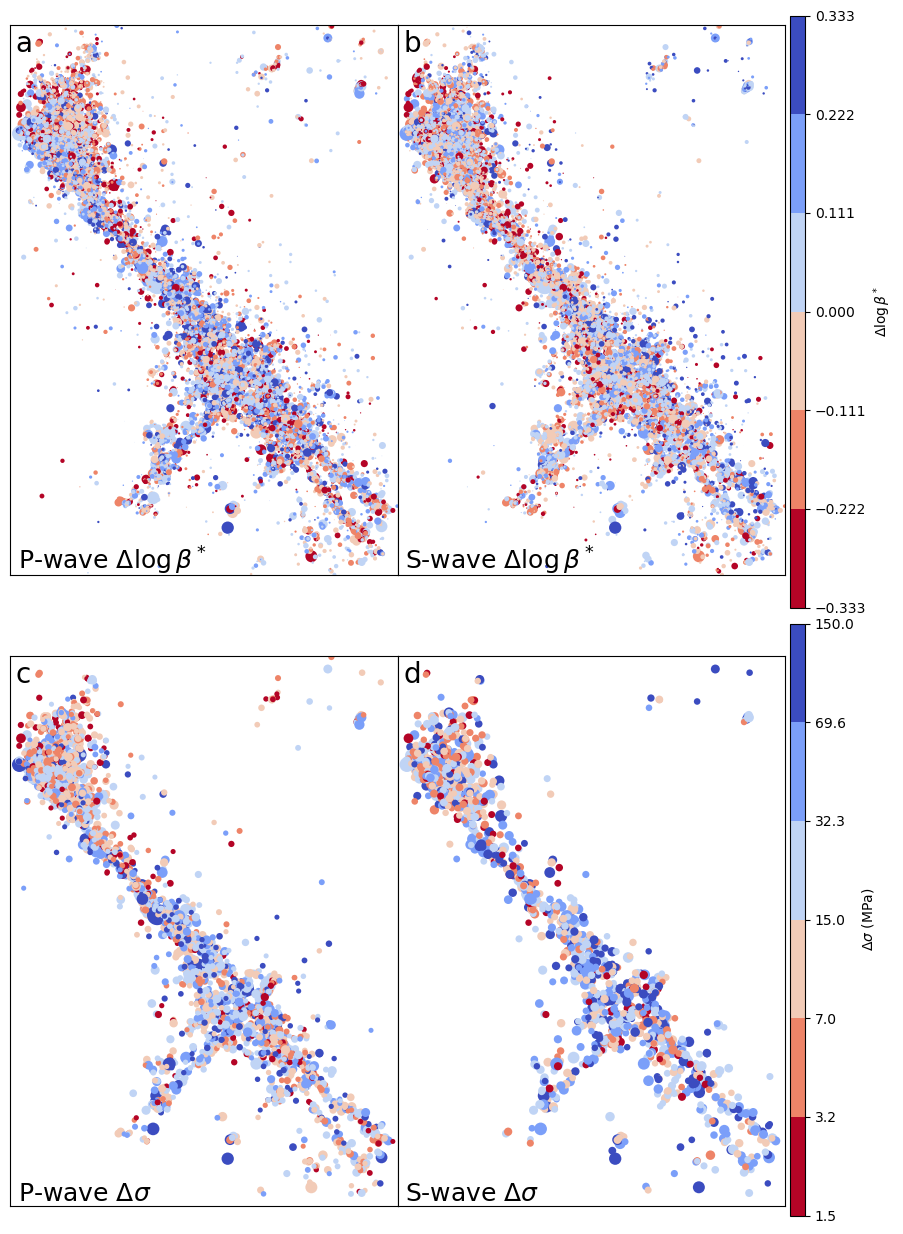

In [17]:
# filtering arrays 
pp = np.ones(len(df), dtype=bool)
pp[np.isnan(df['dlogbeta_p'])] = False  # remove nan values
pp[df['dlogbeta_corr_p']==0.0] = False  # remove entries that couldn't compute dlogbeta_corr
ss = np.ones(len(df), dtype=bool)
ss[np.isnan(df['dlogbeta_s'])] = False
ss[df['dlogbeta_corr_s']==0.0] = False

clim = [-0.333, 0.333]

cmap = mpl.cm.coolwarm.reversed()
bounds = np.linspace(clim[0], clim[1], 7)
cnorm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='neither')
smap = mpl.cm.ScalarMappable(norm=cnorm, cmap=cmap)

df_plot = df[pp]#[df['qmag']>2]
dataname = 'dlogbeta_corr_p'
datatitle = r"$\Delta\log\beta^*$"

# cmap, smap, cnorm = get_colormap(df_plot[dataname].values, method='mediancenter')

# fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(11.2, 16), sharex=True, sharey=True, gridspec_kw={'wspace':0, 'hspace':0})
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 16), sharex=True, sharey=True, gridspec_kw={'wspace':0, 'hspace':0.05})


mapout = mt.plot_map(
    df_plot,
    ax=ax[0,0],
    zoom=1.05,
    cname=dataname,
    cnorm=cnorm,
    smap=smap,
    distinguish_clipped=False,
    bgcolor=(1,1,1),

)

df_plot = df[ss]#[df['qmag']>2.5]
dataname = 'dlogbeta_corr_s'
mapout = mt.plot_map(
    df_plot,
    ax=ax[0,1],
    zoom=1.05,
    cname=dataname,
    cnorm=cnorm,
    smap=smap,
    distinguish_clipped=False,
    bgcolor=(1,1,1),

)

cb_ax = fig.add_axes([0.905,.5,.015,.37])
cbar = plt.colorbar(smap, fraction=0.0405, pad=0.02, aspect=35, 
    cax=cb_ax, extend='neither')
smap.set_clim(clim)

cbar.ax.set_ylabel(r"$\Delta\log\beta^*$")



### OLD DELSIG DATA

clim = [1.5, 150]

cmap = mpl.cm.coolwarm.reversed()
bounds = np.logspace(np.log10(clim[0]), np.log10(clim[1]), 7)
cnorm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='neither')
smap = mpl.cm.ScalarMappable(norm=cnorm, cmap=cmap)

df_plot = ds_p[~np.isnan(ds_p['delsig'])][ds_p['qmag']>2.0]
dataname = 'delsig'
datatitle = r"$\Delta\log\beta^*$"


mapout = mt.plot_map(
    df_plot,
    ax=ax[1,0],
    zoom=1.05,
    cname=dataname,
    cnorm=cnorm,
    smap=smap,
    distinguish_clipped=False,
    bgcolor=(1,1,1),

)

df_plot = ds_s[~np.isnan(ds_s['delsig'])]
df_plot = df_plot[df_plot['qmag']>2.5]
dataname = 'delsig'
mapout = mt.plot_map(
    df_plot,
    ax=ax[1,1],
    zoom=1.05,
    cname=dataname,
    cnorm=cnorm,
    smap=smap,
    distinguish_clipped=False,
    bgcolor=(1,1,1),

)



cb_ax = fig.add_axes([0.905,.12,.015,.37])
cbar = plt.colorbar(smap, fraction=0.0405, pad=0.02, aspect=35, 
    cax=cb_ax, extend='neither')
smap.set_clim(clim)
cbar.ax.set_ylabel(r"$\Delta \sigma$ (MPa)")

for AX in ax.flatten():
    AX.get_xaxis().set_ticks([])
    AX.get_yaxis().set_ticks([])


ax[0,0].annotate(r"P-wave $\Delta\log\beta^*$", xy=(0.02, 0.01), xycoords='axes fraction', fontsize=18)
ax[0,1].annotate(r"S-wave $\Delta\log\beta^*$", xy=(0.02, 0.01), xycoords='axes fraction', fontsize=18)
ax[1,0].annotate(r"P-wave $\Delta \sigma$", xy=(0.02, 0.01), xycoords='axes fraction', fontsize=18)
ax[1,1].annotate(r"S-wave $\Delta \sigma$", xy=(0.02, 0.01), xycoords='axes fraction', fontsize=18)


# panel labels
for n, axes in enumerate(ax.flatten()):
    axes.text(0.015, 0.95, string.ascii_lowercase[n], transform=axes.transAxes, 
        size=20)


# plt.savefig(f"{paper_figure_dir}map_comp.pdf", bbox_inches='tight')

plt.show()



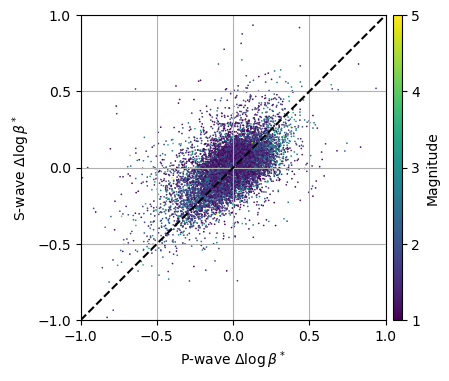

In [8]:

xlim = [-1, 1]


fig, ax = plt.subplots(1,1, figsize=(4,4), constrained_layout=True)
sc = ax.scatter(df['dlogbeta_corr_p'], df['dlogbeta_corr_s'], c=df['qmag'], s=6, marker='.', edgecolors='none', vmin=1.0, vmax=5.0)
ax.plot(xlim, xlim, c='k', linestyle='--')
ax.set_ylim(xlim)
ax.set_xlim(xlim)


ax.set_xlabel(r"P-wave $\Delta\log\beta^*$")
ax.set_ylabel(r"S-wave $\Delta\log\beta^*$")

ax.set_yticks([-1, -0.5, 0, 0.5, 1])
ax.grid(True)
ax.set_aspect('equal')

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=.07)

plt.colorbar(sc, cax=cax)

cax.set_ylabel('Magnitude')
cax.set_yticks([1, 2, 3, 4, 5])

plt.savefig(f"{paper_figure_dir}PS_beta_comparison.pdf", bbox_inches='tight')

plt.show()

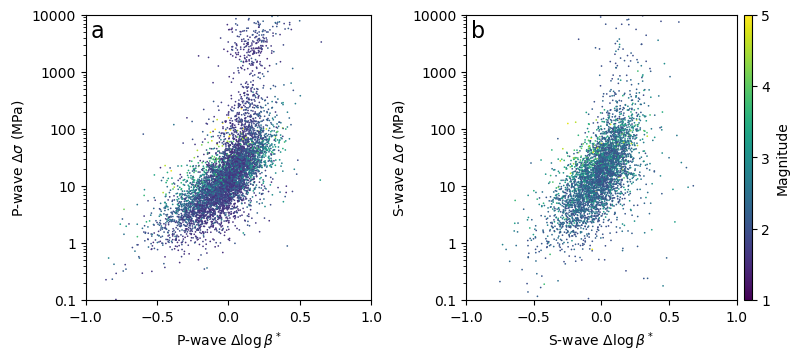

In [9]:

dsylim = [1E-1, 1E4]
xlim = [-1, 1]

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(7.5,3.5),
    layout='constrained')

# ax[0].scatter(df['dlogbeta_corr_p'], df['delsig_p'], c='k', s=3, marker='.', edgecolors='none')
# ax[1].scatter(df['dlogbeta_corr_s'], df['delsig_s'], c='k', s=3, marker='.', edgecolors='none')

sc = ax[0].scatter(df['dlogbeta_corr_p'], df['delsig_p'], c=df['qmag'], s=6, marker='.', edgecolors='none', vmin=1.0, vmax=5.0)
ax[1].scatter(df['dlogbeta_corr_s'], df['delsig_s'], c=df['qmag'], s=6, marker='.', edgecolors='none', vmin=1.0, vmax=5.0)




ax[0].set_yscale('log')
ax[1].set_yscale('log')
ax[0].set_ylim(dsylim)
ax[1].set_ylim(dsylim)

ax[0].set_xlim(xlim)
ax[1].set_xlim(xlim)

ax[0].set_xlabel(r"P-wave $\Delta\log\beta^*$")
ax[1].set_xlabel(r"S-wave $\Delta\log\beta^*$")

ax[0].set_ylabel(r"P-wave $\Delta\sigma$ (MPa)")
ax[1].set_ylabel(r"S-wave $\Delta\sigma$ (MPa)")

ax[0].set_yticks([0.1, 1, 10, 100, 1000, 10000])
ax[1].set_yticks([0.1, 1, 10, 100, 1000, 10000])
ax[0].set_yticklabels([0.1, 1, 10, 100, 1000, 10000])
ax[1].set_yticklabels([0.1, 1, 10, 100, 1000, 10000])

divider = make_axes_locatable(ax[1])
cax = divider.append_axes("right", size="3%", pad=.07)

plt.colorbar(sc, cax=cax)
cax.set_ylabel('Magnitude')
cax.set_yticks([1, 2, 3, 4, 5])

# panel labels
for n, axes in enumerate(ax.flatten()):
    axes.text(0.019, 0.92, string.ascii_lowercase[n], transform=axes.transAxes, 
        size=16)

plt.savefig(f"{paper_figure_dir}PS_beta_delsig_comparison.pdf", bbox_inches='tight')
plt.show()


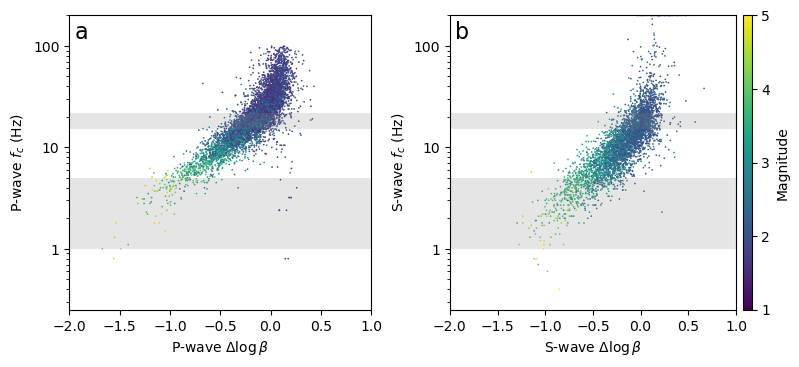

In [10]:
from matplotlib.patches import Rectangle


fcylim = [10**(-0.6), 200.0]
xlim = [-2, 1]

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(7.5,3.5),
    layout='constrained')

# ax[0].scatter(df['dlogbeta_corr_p'], df['delsig_p'], c='k', s=3, marker='.', edgecolors='none')
# ax[1].scatter(df['dlogbeta_corr_s'], df['delsig_s'], c='k', s=3, marker='.', edgecolors='none')

sc = ax[0].scatter(df['dlogbeta_p'], df['fc_p'], c=df['qmag'], s=6, marker='.', edgecolors='none', vmin=1.0, vmax=5.0)
ax[1].scatter(df['dlogbeta_s'], df['fc_s'], c=df['qmag'], s=6, marker='.', edgecolors='none', vmin=1.0, vmax=5.0)

# grey rectangle for low_beta_window_p
ax[0].add_patch(Rectangle((xlim[0], low_beta_window_p[0]), xlim[1]-xlim[0], low_beta_window_p[1]-low_beta_window_p[0], fill=True, facecolor='gray', alpha=0.2, edgecolor='none'))
ax[0].add_patch(Rectangle((xlim[0], high_beta_window_p[0]), xlim[1]-xlim[0], high_beta_window_p[1]-high_beta_window_p[0], fill=True, facecolor='gray', alpha=0.2, edgecolor='none'))

ax[1].add_patch(Rectangle((xlim[0], low_beta_window_s[0]), xlim[1]-xlim[0], low_beta_window_s[1]-low_beta_window_s[0], fill=True, facecolor='gray', alpha=0.2, edgecolor='none'))
ax[1].add_patch(Rectangle((xlim[0], high_beta_window_s[0]), xlim[1]-xlim[0], high_beta_window_s[1]-high_beta_window_s[0], fill=True, facecolor='gray', alpha=0.2, edgecolor='none'))


ax[0].set_yscale('log')
ax[1].set_yscale('log')
ax[0].set_ylim(fcylim)
ax[1].set_ylim(fcylim)

ax[0].set_xlim(xlim)
ax[1].set_xlim(xlim)

ax[0].set_xlabel(r"P-wave $\Delta\log\beta$")
ax[1].set_xlabel(r"S-wave $\Delta\log\beta$")

ax[0].set_ylabel(r"P-wave $f_c$ (Hz)")
ax[1].set_ylabel(r"S-wave $f_c$ (Hz)")

ax[0].set_yticks([1, 10, 100])
ax[0].set_yticklabels([1, 10, 100])
ax[1].set_yticks([1, 10, 100])
ax[1].set_yticklabels([1, 10, 100])
# ax[0].set_yticks([0.3, 1, 3, 10, 30, 100])
# ax[0].set_yticklabels([0.3, 1, 3, 10, 30, 100])

divider = make_axes_locatable(ax[1])
cax = divider.append_axes("right", size="3%", pad=.07)

plt.colorbar(sc, cax=cax)
cax.set_ylabel('Magnitude')
cax.set_yticks([1, 2, 3, 4, 5])

# panel labels
for n, axes in enumerate(ax.flatten()):
    axes.text(0.019, 0.92, string.ascii_lowercase[n], transform=axes.transAxes, 
        size=16)
        
plt.savefig(f"{paper_figure_dir}PS_beta_fc_comparison.pdf", bbox_inches='tight')
plt.show()

# outliers

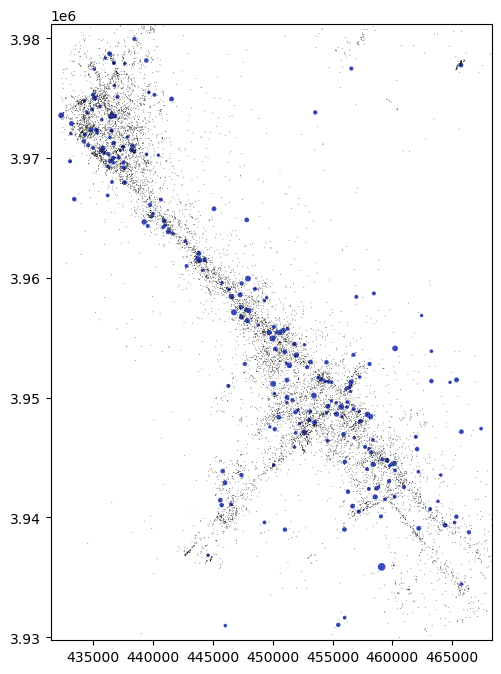

In [11]:
df_outliers = df[df['delsig_p']>1000.0].reset_index(drop=True)


fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 8), sharex=True, sharey=True, gridspec_kw={'wspace':0, 'hspace':0})


mapout = mt.plot_map(
    df_outliers,
    ax=ax,
    zoom=1.05,
    cname='delsig_p',
    cnorm=cnorm,
    smap=smap,
    distinguish_clipped=False,
    bgcolor=(1,1,1),

)

ax.scatter(df['easting'], df['northing'], c='k', s=1, marker='.', edgecolors='none')



In [12]:
import stressdrop_file_IO as sdio
importlib.reload(sdio)

# proc_q = sdio.read_proc_q("/Users/ivandevert/projects/ridgecrest2019_prev/proc/spectral/02_procspec/out.proc_q")[['event_id', 's1', 's2']]
kwargs = {
    "filepath": "/Users/ivandevert/projects/ridgecrest2019_prev/proc/spectral/10_pegfc/out.pegfcx.specfit",
    "header_names":['event_id', 'qyr', 'qmon', 'qday', 'qhr', 'qmn', 'qsc', 
                    'qmag', 'qlat', 'qlon', 'qdep', 'nst', 'negf', 'sig0', 
                    'fc', 'fitrms', 'delsig', 'qmag_2', 'qmagpred', 
                    'qmag_mom', 'fmom', 'dsig1', 'dsig2', 'avalue', 'bvalue',
                    'nf', 'df', 'j1','j2','j3', 'j4','fmin','fmax','j5','j6'], 
    "data_names":["s1", "s2", "s3"], 
    "header_types":None, 
    "n_header_lines":2, 
    "delimiter":None
}


pegfcx = sdio.read_event_data_file_(**kwargs)

# pegfcx

i don't think this is working right now
[[ 2.89392495e+00  2.71489525e+00  2.88257152e-01]
 [ 3.13654351e+00  2.69578505e+00  4.77013085e-03]
 [ 2.99121284e+00  2.64303470e+00 -1.25762094e-02]
 ...
 [-9.26248848e-01 -1.14255929e+00  9.06689107e-01]
 [-9.97517169e-01 -1.15593135e+00  9.25145686e-01]
 [-2.28556335e-01 -1.16910839e+00  1.25014096e-38]]


In [13]:
pegfcx['event_id'].values

array([37218988, 37219164, 37219180, ..., 38590983, 38591663, 38592095])

In [14]:
proc_q = proc_q[proc_q['event_id'].isin(df_outliers['event_id'])]

# merge columns s1 and s2 onto df_outliers
df_outliers = df_outliers.merge(proc_q, how='left', on='event_id')


NameError: name 'proc_q' is not defined

In [ ]:

plt.figure()
plt.plot(f, df_outliers['s2'].values[6], c='k', linewidth=0.5)
plt.xscale('log')
plt.show()




In [15]:

corrcoef = np.corrcoef(np.log10(df['delsig_p'][pp].values.astype(float)), df['dlogbeta_corr_p'][pp].values)[0,1]


txt = '\n'.join([
    f"correlation: {corrcoef:.4f}", 
    f"Calib. events: {calib_mag_range[0]:.1f}<M<{calib_mag_range[1]:.1f}",
    f"Calib. dmax: {calib_rmax:.1f} km",
    f"Calib. zmax: {calib_zmax:.1f} km",
    f"Calib. STN band:  {stn_band[0]:.1f}-{stn_band[1]:.1f} Hz",
    f"n calib. minimum: {ncalib_min}",
    f"Low band: {low_beta_band[0]:.1f}-{low_beta_band[1]:.1f} Hz",
    f"High band: {high_beta_band[0]:.1f}-{high_beta_band[1]:.1f} Hz",
])

plt.figure()
ax = plt.gca()
plt.scatter(df['qmag'], df['dlogbeta_corr_p'], c='k', s=3, marker='.', edgecolors='none')
plt.scatter(df['qmag'], df['dlogbeta_p'], c='r', s=3, marker='.', edgecolors='none')
plt.ylim([-0.8, 0.8])
ax.text(0.98, 0.04, txt, va='bottom', ha='right', transform=ax.transAxes)
plt.xlabel('Catalog magnitude')
plt.ylabel('Corrected logbeta')
plt.title("Magnitude-corrected logbeta vs. catalog magnitude")
# plt.savefig(f"figs/{phase}_logbeta_mag.pdf")
plt.show()

plt.figure()
ax = plt.gca()
plt.scatter(df['delsig_p'], df['dlogbeta_corr_p'], c=df['qmag'], s=3, marker='.')
plt.xscale('log')
plt.ylim([-0.8, 0.8])
plt.xlim([0.5, 5000.0])
ax.text(0.98, 0.04, txt, va='bottom', ha='right', transform=ax.transAxes)
plt.xlabel('Stress drop (MPa)')
plt.ylabel('Corrected logbeta')
plt.title("All corrected logbeta results")
# plt.savefig(f"figs/{phase}_delsig_correlation.pdf")
plt.show()
plt.close()


# ds = df_target_ev[~np.isnan(df_target_ev['dlogbeta'])].reset_index(drop=True)
# ds['dlogbeta_corr'] = ds['dlogbeta'].values

# # indices where dlogbeta was calculated
# not_nan = ~np.isnan(ds['dlogbeta'])

# edges = np.arange(1, 7.3, 0.1)
# for i in range(len(edges)-1):
#     inrange = np.logical_and(ds['qmag']>=edges[i], ds['qmag']<edges[i+1])
#     keep = np.where(np.logical_and(inrange, not_nan))[0]
#     if np.sum(keep) > 0:
#         dlogbeta = ds['dlogbeta'].values[keep]
#         ds.loc[keep, 'dlogbeta_corr'] -= np.nanmedian(dlogbeta)


# # remove records with delsig==0
# ds = ds[ds['delsig'] != 0].reset_index(drop=True)

# corrcoef = np.corrcoef(np.log10(ds['delsig'].values.astype(float)), ds['dlogbeta_corr'].values)[0,1]


# txt = '\n'.join([
#     f"correlation: {corrcoef:.4f}", 
#     f"Calib. events: {calib_mag_range[0]:.1f}<M<{calib_mag_range[1]:.1f}",
#     f"Calib. dmax: {calib_rmax:.1f} km",
#     f"Calib. zmax: {calib_zmax:.1f} km",
#     f"Calib. STN band:  {stn_band[0]:.1f}-{stn_band[1]:.1f} Hz",
#     f"n calib. minimum: {ncalib_min}",
#     f"Low band: {low_beta_band[0]:.1f}-{low_beta_band[1]:.1f} Hz",
#     f"High band: {high_beta_band[0]:.1f}-{high_beta_band[1]:.1f} Hz",
# ])

# plt.figure()
# ax = plt.gca()
# plt.scatter(ds['delsig'], ds['dlogbeta_corr'], c=ds['qmag'], s=3, marker='.')
# plt.xscale('log')
# plt.ylim([-0.8, 0.8])
# plt.xlim([0.5, 5000.0])
# ax.text(0.98, 0.04, txt, va='bottom', ha='right', transform=ax.transAxes)
# plt.xlabel('Stress drop (MPa)')
# plt.ylabel('Corrected logbeta')
# # plt.savefig(f"figs/corr/{n}_{phase}_correlation.pdf")
# plt.show()
# plt.close()


/var/folders/n9/y3b20y1x2dx7n3qq1qn2cn2m000jzz/T/ipykernel_2247/2210481747.py:1: RuntimeWarning: divide by zero encountered in log10
  corrcoef = np.corrcoef(np.log10(df['delsig_p'][pp].values.astype(float)), df['dlogbeta_corr_p'][pp].values)[0,1]
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/lib/function_base.py:2742: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]


NameError: name 'calib_mag_range' is not defined

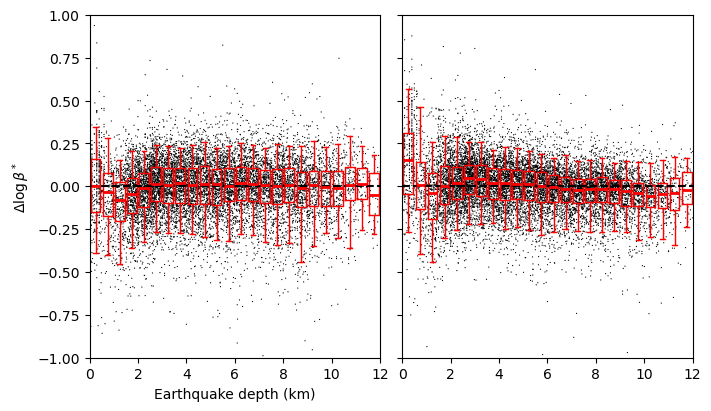

In [16]:
# Depth variation

dx = 0.2
edges = np.arange(0, 20, 0.5)

fig, ax = plt.subplots(1,2,figsize=(7,4), sharex=True, sharey=True, layout='constrained')
ax[0].scatter(df['qdep'][pp], df['dlogbeta_corr_p'][pp], c='k', s=3, marker='.', edgecolors='none')
ax[1].scatter(df['qdep'][ss], df['dlogbeta_corr_s'][ss], c='k', s=3, marker='.', edgecolors='none')
boxplot(df['qdep'][pp], df['dlogbeta_corr_p'][pp], xbins=edges, ax=ax[0], color='r')
boxplot(df['qdep'][ss], df['dlogbeta_corr_s'][ss], xbins=edges, ax=ax[1], color='r')
ax[0].set_ylim([-1, 1])
ax[0].set_xlim([0, 12])
ax[0].set_xlabel('Earthquake depth (km)')
ax[0].set_ylabel(r'$\Delta\log\beta^*$')
ax[0].axhline(0, c='k', linestyle='--')
ax[1].axhline(0, c='k', linestyle='--')
# plt.savefig(f"figs/dlogbeta_dep_{phase}.pdf", bbox_inches='tight')
plt.show()

In [ ]:
# dx = 0.2
# edges = np.arange(1.0, 7.3, dx)


# fig, axs = plt.subplots(1,2, figsize=(8,4), layout='constrained', sharex=True)

# axs[0].scatter(ds['qmag'], ds['fc'], c='k', s=1, edgecolors='none')
# axs[1].scatter(ds['qmag'], ds['delsig'], c='k', s=1, edgecolors='none')

# boxplot(ds['qmag'], ds['fc'], xbins=edges, ax=axs[0], color='r')
# boxplot(ds['qmag'], ds['delsig'], xbins=edges, ax=axs[1], color='r')

# axs[0].set_yscale('log')
# axs[1].set_yscale('log')

# axs[0].set_ylabel('Corner frequency (Hz)')
# axs[1].set_ylabel('Stress drop (MPa)')

# axs[0].set_xlim([0.8,5.1])
# axs[0].set_ylim([1E-1, 1E3])

# axs[1].set_ylim([1E-1, 1E2])

# # plt.savefig(paper_figure_dir + "syn_source_params.pdf", bbox_inches='tight')
# plt.show()

In [ ]:
np.log10(ds['delsig']).describe()

In [ ]:
# df_plot['qmag'].describe()

In [ ]:
# for i in range(df_['stind'].max()):
#     nsta = len(df_[df_['stind']==i])
#     print(f'{nsta} in {i}')

In [ ]:
# dependents = ['deldist', 's1', 's2', 'logbeta']
# st_dep = ['stname', 'slat', 'slon', 'selev', 'sx', 'sy', 'stind']

In [ ]:
dependents


In [ ]:
ds

In [17]:
corrcoef = np.corrcoef(np.log10(ds['fc'].values.astype(float)), ds['dlogbeta'].values)[0,1]


txt = '\n'.join([
    f"Correlation: {corrcoef:.4f}", 
    f"Calib. events: {calib_mag_range[0]:.1f}<M<{calib_mag_range[1]:.1f}",
    f"Calib. dmax: {calib_rmax:.1f} km",
    f"Calib. zmax: {calib_zmax:.1f} km",
    f"n calib. minimum: {ncalib_min}",
    f"Low band: {low_beta_band[0]:.1f}-{low_beta_band[1]:.1f} Hz",
    f"High band: {high_beta_band[0]:.1f}-{high_beta_band[1]:.1f} Hz",
])

plt.figure(figsize=(5,5))
ax = plt.gca()
sc = plt.scatter(ds['fc'], ds['dlogbeta'], c=ds['qmag'], s=3, marker='.', vmin=1.6, vmax=5)
plt.xscale('log')
# plt.ylim([-0.8, 0.8])
plt.xlim([0.5, 200.0])
ax.text(0.98, 0.04, txt, va='bottom', ha='right', transform=ax.transAxes)
plt.xlabel('Corner frequency (Hz)')
plt.ylabel(r'$\Delta\log\beta$')
fig = sc.figure
cax = fig.add_axes([0.91, 0.1, 0.02, 0.8])
fig.colorbar(sc, cax=cax)
cax.set_ylabel('Magnitude')
ax.axvline(low_beta_band[0], ls='--', c='k')
ax.axvline(low_beta_band[1], ls='--', c='k')
ax.axvline(high_beta_band[0], ls='--', c='k')
ax.axvline(high_beta_band[1], ls='--', c='k')
# plt.savefig(f"figs/{phase}_fc_correlation.pdf", bbox_inches='tight')
plt.savefig(paper_figure_dir + f"{phase}_fc_correlation.pdf", bbox_inches='tight')
plt.show()








# corrcoef = np.corrcoef(np.log10(ds['m0'].values.astype(float)), ds['dlogbeta'].values)[0,1]


# txt = '\n'.join([
#     f"Correlation: {corrcoef:.4f}", 
#     f"Calib. events: {calib_mag_range[0]:.1f}<M<{calib_mag_range[1]:.1f}",
#     f"Calib. dmax: {calib_rmax:.1f} km",
#     f"Calib. zmax: {calib_zmax:.1f} km",
#     f"n calib. minimum: {ncalib_min}",
#     f"Low band: {low_beta_band[0]:.1f}-{low_beta_band[1]:.1f} Hz",
#     f"High band: {high_beta_band[0]:.1f}-{high_beta_band[1]:.1f} Hz",
# ])

# plt.figure()
# ax = plt.gca()
# sc = plt.scatter(ds['m0'], ds['dlogbeta'], c=ds['qmag'], s=3, marker='.', vmin=1.6, vmax=5)
# plt.xscale('log')
# # plt.ylim([-0.8, 0.8])
# ax.text(0.98, 0.04, txt, va='bottom', ha='right', transform=ax.transAxes)
# plt.xlabel('Seismic Moment')
# plt.ylabel(r'$\Delta\log\beta$')
# fig = sc.figure
# cax = fig.add_axes([0.91, 0.1, 0.02, 0.8])
# fig.colorbar(sc, cax=cax)
# cax.set_ylabel('Magnitude')
# plt.savefig(f"figs/{phase}m0_correlation.pdf")
# plt.show()







corrcoef = np.corrcoef(np.log10(ds['delsig'].values.astype(float)), ds['dlogbeta_corr'].values)[0,1]

txt = '\n'.join([
    f"Correlation: {corrcoef:.4f}", 
    f"Calib. events: {calib_mag_range[0]:.1f}<M<{calib_mag_range[1]:.1f}",
    f"Calib. dmax: {calib_rmax:.1f} km",
    f"Calib. zmax: {calib_zmax:.1f} km",
    f"n calib. minimum: {ncalib_min}",
    f"Low band: {low_beta_band[0]:.1f}-{low_beta_band[1]:.1f} Hz",
    f"High band: {high_beta_band[0]:.1f}-{high_beta_band[1]:.1f} Hz",
])

plt.figure(figsize=(5,5))
ax = plt.gca()
sc = plt.scatter(ds['delsig'], ds['dlogbeta_corr'], c=ds['qmag'], s=3, marker='.', vmin=1.6, vmax=5)
plt.xscale('log')
plt.ylim([-0.8, 0.8])
plt.xlim([0.5, 5000.0])
ax.text(0.98, 0.04, txt, va='bottom', ha='right', transform=ax.transAxes)
plt.xlabel('Stress drop (MPa)')
plt.ylabel(r'$\Delta\log\beta^*$')
# plt.title("All corrected logbeta results")
# colorbar, Magnitude
fig = sc.figure
cax = fig.add_axes([0.91, 0.1, 0.02, 0.8])
fig.colorbar(sc, cax=cax)
cax.set_ylabel('Magnitude')
# plt.savefig(f"figs/{phase}_delsig_correlation.pdf", bbox_inches='tight')
plt.savefig(paper_figure_dir + f"{phase}_delsig_correlation.pdf", bbox_inches='tight')
plt.show()


KeyError: 'fc'

NameError: name 'df_target_ev' is not defined

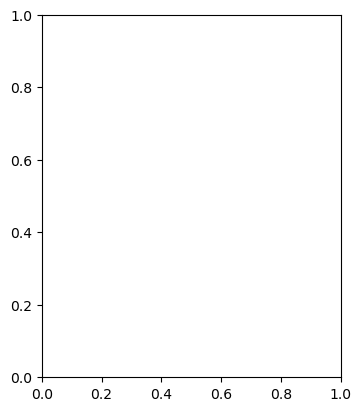

In [18]:
dx = 0.2
edges = np.arange(1.0, 7.3, dx)

plt.figure(figsize=(3.5,4), layout='constrained')
ax = plt.gca()
plt.scatter(df_target_ev['qmag'], df_target_ev['dlogbeta_corr'], c='k', s=3, marker='.', edgecolors='none')
# plt.scatter(df_target_ev['qmag'], df_target_ev['dlogbeta'], c='r', s=3, marker='.', edgecolors='none')
boxplot(df_target_ev['qmag'], df_target_ev['dlogbeta_corr'], xbins=edges, ax=ax, color='r')
plt.ylim([-2, 2])
plt.xlim([1.0, 5.0])
# ax.text(0.98, 0.04, txt, va='bottom', ha='right', transform=ax.transAxes)
plt.xlabel('Catalog magnitude')
plt.ylabel(r'$\Delta\log\beta^*$')
# plt.title("Magnitude-corrected logbeta vs. catalog magnitude")
# plt.savefig(f"figs/dlogbeta_corr.pdf", bbox_inches='tight')
plt.show()


NameError: name 'df_target_ev' is not defined

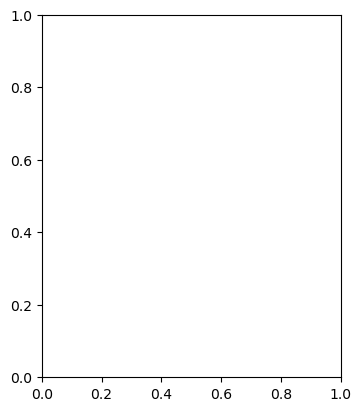

In [19]:
dx = 0.2
edges = np.arange(0, 20, 0.5)

plt.figure(figsize=(3.5,4), layout='constrained')
ax = plt.gca()
plt.scatter(df_target_ev['qdep'], df_target_ev['dlogbeta_corr'], c='k', s=3, marker='.', edgecolors='none')
# plt.scatter(df_target_ev['qmag'], df_target_ev['dlogbeta'], c='r', s=3, marker='.', edgecolors='none')
boxplot(df_target_ev['qdep'], df_target_ev['dlogbeta_corr'], xbins=edges, ax=ax, color='r')
plt.ylim([-2, 2])
plt.xlim([0, 12])
# ax.text(0.98, 0.04, txt, va='bottom', ha='right', transform=ax.transAxes)
plt.xlabel('Earthquake depth (km)')
plt.ylabel(r'$\Delta\log\beta^*$')
# plt.title("Magnitude-corrected logbeta vs. catalog magnitude")
# plt.savefig(f"figs/dlogbeta_dep.pdf", bbox_inches='tight')
plt.show()

In [ ]:
df

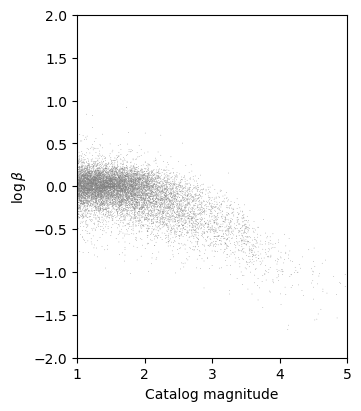

In [20]:
scatter_kwargs = {'s':1, 'marker':'.', 'edgecolors':'none'}

dx = 0.2
edges = np.arange(1.0, 7.3, dx)

plt.figure(figsize=(3.5,4), layout='constrained')
ax = plt.gca()
# ax.scatter(df['qmag'], df['logbeta'], c='k', s=3, marker='.', edgecolors='none')
# plt.boxplot(df['logbeta'].values, widths=0.5, sym='.', whis=(5, 95))
ax.scatter(df['qmag'], df['dlogbeta_p'], color='gray', **scatter_kwargs)
boxplot(df['qmag'], df['dlogbeta_p'], xbins=edges, ax=ax, color='r')
plt.xlim([1.0, 5.0])
plt.ylim([-2,2])
plt.xlabel('Catalog magnitude')
plt.ylabel(r'$\log\beta$')
# plt.savefig(f"figs/all_logbeta.png", bbox_inches='tight', dpi=600)
plt.show()


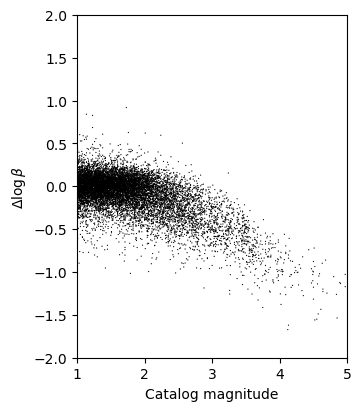

In [21]:
plt.figure(figsize=(3.5,4), layout='constrained')
ax = plt.gca()
# plt.scatter(df_target_ev['qmag'], df_target_ev['dlogbeta_corr'], c='k', s=3, marker='.', edgecolors='none')
plt.scatter(df['qmag'], df['dlogbeta_p'], c='k', s=3, marker='.', edgecolors='none')
boxplot(df['qmag'], df['dlogbeta_p'], xbins=edges, ax=ax, color='r')
plt.ylim([-2, 2])
# ax.text(0.98, 0.04, txt, va='bottom', ha='right', transform=ax.transAxes)
plt.xlabel('Catalog magnitude')
plt.ylabel(r'$\Delta\log\beta$')
plt.xlim([1.0, 5.0])
# plt.savefig(f"figs/event_dlogbeta.pdf", bbox_inches='tight')
plt.show()

In [22]:
df_plot['qmag'].describe()

count    1673.000000
mean        3.061913
std         0.488467
min         2.510000
25%         2.680000
50%         2.930000
75%         3.340000
max         6.400000
Name: qmag, dtype: float64

/Users/ivandevert/prog/mapping-tools/mapping_tools.py:84: RuntimeWarning: invalid value encountered in log10
  cticks = np.logspace(np.log10(clim[0]), np.log10(clim[1]), 5)


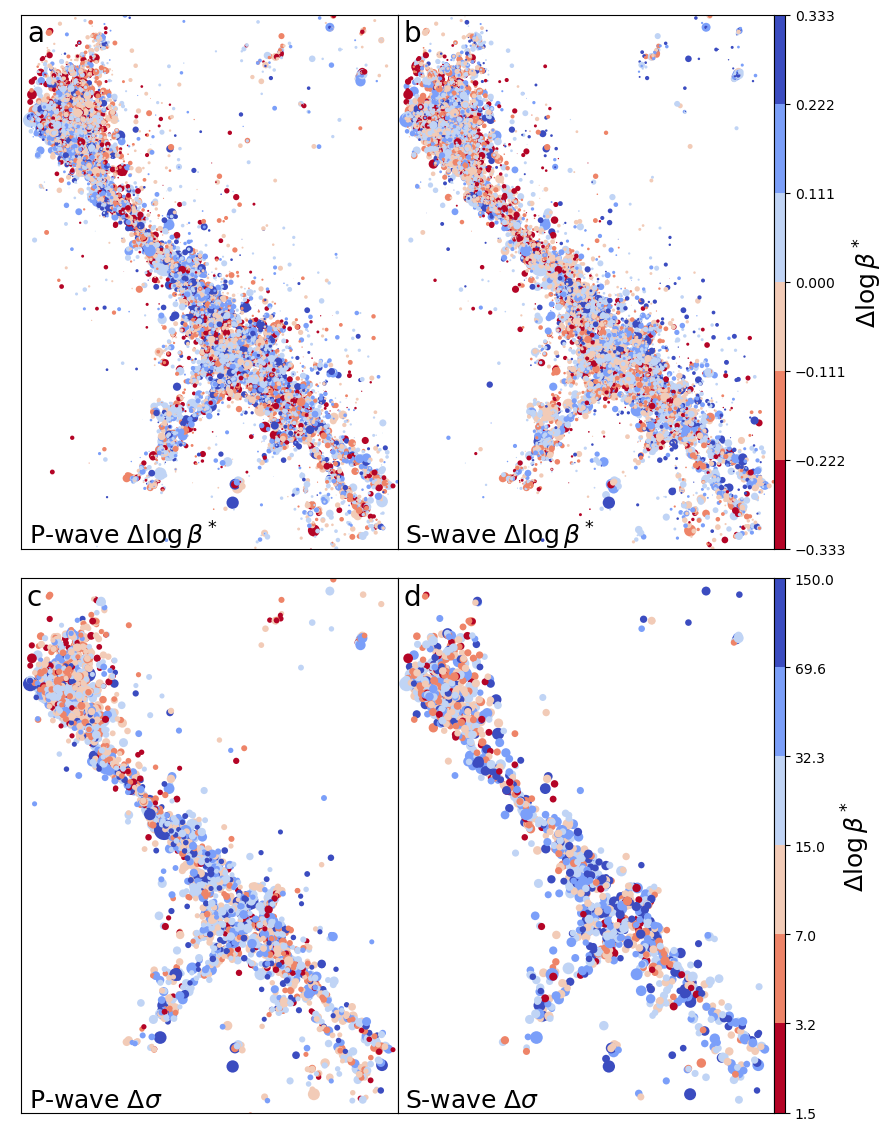

In [47]:
# specifically for poster figure
poster_figure_dir = "/Users/ivandevert/Documents/Conferences/2025-04 SSA/Poster/figures/"

# filtering arrays 
pp = np.ones(len(df), dtype=bool)
pp[np.isnan(df['dlogbeta_p'])] = False  # remove nan values
pp[df['dlogbeta_corr_p']==0.0] = False  # remove entries that couldn't compute dlogbeta_corr
ss = np.ones(len(df), dtype=bool)
ss[np.isnan(df['dlogbeta_s'])] = False
ss[df['dlogbeta_corr_s']==0.0] = False

clim = [-0.333, 0.333]

cmap = mpl.cm.coolwarm.reversed()
bounds = np.linspace(clim[0], clim[1], 7)
cnorm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='neither')
smap = mpl.cm.ScalarMappable(norm=cnorm, cmap=cmap)

df_plot = df[pp]#[df['qmag']>2]
dataname = 'dlogbeta_corr_p'
datatitle = r"$\Delta\log\beta^*$"

# cmap, smap, cnorm = get_colormap(df_plot[dataname].values, method='mediancenter')

# fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(11.2, 16), sharex=True, sharey=True, gridspec_kw={'wspace':0, 'hspace':0})
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 14.5), sharex=True, sharey=True, gridspec_kw={'wspace':0, 'hspace':0.02})




mapout = mt.plot_map(
    df_plot,
    ax=ax[0,0],
    zoom=1.05,
    cname=dataname,
    cnorm=cnorm,
    smap=smap,
    distinguish_clipped=False,
    bgcolor=(1,1,1),

)

df_plot = df[ss]#[df['qmag']>2.5]
dataname = 'dlogbeta_corr_s'
mapout = mt.plot_map(
    df_plot,
    ax=ax[0,1],
    zoom=1.05,
    cname=dataname,
    cnorm=cnorm,
    smap=smap,
    distinguish_clipped=False,
    bgcolor=(1,1,1),

)

divider1 = make_axes_locatable(ax[0,1])
cax1 = divider1.append_axes("right", size="3%", pad=.00)

div1 = make_axes_locatable(ax[0,0])
c1 = div1.append_axes("left", size="3%", pad=.00)
c1.set_axis_off()



plt.colorbar(smap, cax=cax1)

cax1.set_ylabel(r"$\Delta\log\beta^*$", fontsize=18)

# cb_ax = fig.add_axes([0.905,.5,.015,.37])
# cbar = plt.colorbar(smap, fraction=0.0405, pad=0.02, aspect=35, 
#     cax=cb_ax, extend='neither')
# smap.set_clim(clim)

# cbar.ax.set_ylabel(r"$\Delta\log\beta^*$")



### OLD DELSIG DATA

clim = [1.5, 150]

cmap = mpl.cm.coolwarm.reversed()
bounds = np.logspace(np.log10(clim[0]), np.log10(clim[1]), 7)
cnorm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='neither')
smap = mpl.cm.ScalarMappable(norm=cnorm, cmap=cmap)

df_plot = ds_p[~np.isnan(ds_p['delsig'])][ds_p['qmag']>2.0]
dataname = 'delsig'
datatitle = r"$\Delta\log\beta^*$"


mapout = mt.plot_map(
    df_plot,
    ax=ax[1,0],
    zoom=1.05,
    cname=dataname,
    cnorm=cnorm,
    smap=smap,
    distinguish_clipped=False,
    bgcolor=(1,1,1),

)

df_plot = ds_s[~np.isnan(ds_s['delsig'])]
df_plot = df_plot[df_plot['qmag']>2.5]
dataname = 'delsig'
mapout = mt.plot_map(
    df_plot,
    ax=ax[1,1],
    zoom=1.05,
    cname=dataname,
    cnorm=cnorm,
    smap=smap,
    distinguish_clipped=False,
    bgcolor=(1,1,1),

)


divider2 = make_axes_locatable(ax[1,1])
cax2 = divider2.append_axes("right", size="3%", pad=.00)
div2 = make_axes_locatable(ax[1,0])
c2 = div2.append_axes("left", size="3%", pad=.00)
c2.set_axis_off()


plt.colorbar(smap, cax=cax2)
cax2.set_ylabel(r"$\Delta\log\beta^*$", fontsize=18)


# cb_ax = fig.add_axes([0.905,.12,.015,.37])
# cbar = plt.colorbar(smap, fraction=0.0405, pad=0.02, aspect=35, 
#     cax=cb_ax, extend='neither')
# smap.set_clim(clim)
# cbar.ax.set_ylabel(r"$\Delta \sigma$ (MPa)")

for AX in ax.flatten():
    AX.get_xaxis().set_ticks([])
    AX.get_yaxis().set_ticks([])


ax[0,0].annotate(r"P-wave $\Delta\log\beta^*$", xy=(0.02, 0.01), xycoords='axes fraction', fontsize=18)
ax[0,1].annotate(r"S-wave $\Delta\log\beta^*$", xy=(0.02, 0.01), xycoords='axes fraction', fontsize=18)
ax[1,0].annotate(r"P-wave $\Delta \sigma$", xy=(0.02, 0.01), xycoords='axes fraction', fontsize=18)
ax[1,1].annotate(r"S-wave $\Delta \sigma$", xy=(0.02, 0.01), xycoords='axes fraction', fontsize=18)



# panel labels
for n, axes in enumerate(ax.flatten()):
    axes.text(0.015, 0.95, string.ascii_lowercase[n], transform=axes.transAxes, 
        size=20)


plt.savefig(f"{poster_figure_dir}map_comp.pdf", bbox_inches='tight')
plt.savefig(f"{poster_figure_dir}map_comp.png", bbox_inches='tight', dpi=600)

plt.show()


<Axes: >

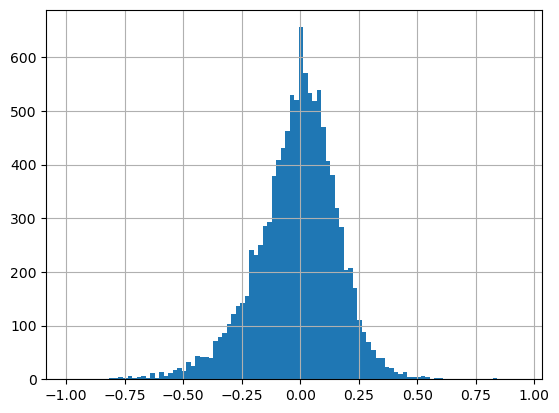

In [53]:
df_plot = df[ss]

df_plot['dlogbeta_corr_p'].describe()

# # plot hist of dlogbeta_corr_p
df_plot['dlogbeta_corr_p'].hist(bins=100)


# df_plot['dlogbeta_corr_s'].hist(bins=100)
